# Supplementary Material — 3. Applications and Implications

Companion notebook to *Polynomial Multiplication for Post-Match Soccer Outcome Probabilities*.

The pooled evaluation in `02_evaluation.ipynb` shows that — averaged over 1823 matches —
Polynomial Multiplication tracks empirical goal and scoreline distributions more closely
than Double Poisson, Bivariate Poisson or Dixon–Coles. This notebook flips the lens from
*evaluation* to *application*: we pick **two real matches with nearly identical home/away
xG sums but very different per-shot xG distributions** and show, side by side, what the
different forecasting approaches imply for them.

The point: methods that only see the xG *sum* (Double Poisson, Dixon–Coles, Bivariate
Poisson) cannot distinguish these two matches; Polynomial Multiplication, which sees the
individual shot xG values, does — and the implied goal/score distributions diverge
accordingly.

## Sections
1. Load data and fit the Dixon–Coles dependence parameter per league.
2. Search for candidate match pairs (similar xG sums, different per-shot xG variance).
3. Pick a pair (the search output is explicit so the choice can be reviewed and replaced).
4. Fetch shot-level event data from StatsBomb (locations, outcomes).
5. Shot maps for both matches.
6. Expected goal-count distributions under Poisson Binomial.
7. Three-outcome probabilities under Poisson Binomial vs Dixon–Coles plus actual outcome.
8. Scoreline heatmaps under both approaches with the realised score highlighted.

In [1]:
import json
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve() / 'modules'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle, Circle, Arc
import seaborn as sns

from data_loading import load_competition_data
from probability_generation import (
    poisson_binomial_pmf,
    dixon_coles_matrix,
    fit_dixon_coles_rho,
    scoreline_matrix_from_pmfs,
    outcome_probs_from_scoreline,
)

sns.set_theme(context='notebook', style='whitegrid')

INPUT_DIR = Path('..') / '..' / 'data' / 'input_data'
FIG_DIR   = Path('figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

LEAGUES = ['epl_1516', 'bundesliga_1516', 'laliga_1516', 'seriea_1516', 'ligue1_1516']
MAX_GOALS = 10

## 1. Load match summary data

Re-use the per-league input parquets produced by `00_data_acquisition.ipynb`.
Each row carries the per-team xG sum *and* the JSON list of per-shot xG values
we need for the Poisson Binomial.

In [2]:
def _parse_xg_list(v):
    if isinstance(v, str):
        return [float(x) for x in json.loads(v) if x is not None]
    if isinstance(v, (list, np.ndarray)):
        return [float(x) for x in v if x is not None]
    return []

league_dfs = {}
for slug in LEAGUES:
    d = load_competition_data(INPUT_DIR / f'{slug}.parquet')
    d['league_slug'] = slug
    league_dfs[slug] = d

matches = pd.concat(league_dfs.values(), ignore_index=True)
matches['home_xg_list'] = matches['home_xg_values'].apply(_parse_xg_list)
matches['away_xg_list'] = matches['away_xg_values'].apply(_parse_xg_list)
matches['n_home_shots'] = matches['home_xg_list'].apply(len)
matches['n_away_shots'] = matches['away_xg_list'].apply(len)

print(f'Loaded {len(matches)} matches across {len(LEAGUES)} leagues.')
matches[['league_slug', 'home_team', 'away_team', 'home_xg', 'away_xg',
         'home_goals', 'away_goals', 'n_home_shots', 'n_away_shots']].head()

Loaded 1823 matches across 5 leagues.


,league_slug,home_team,away_team,home_xg,away_xg,home_goals,away_goals,n_home_shots,n_away_shots
0,epl_1516,Swansea City,AFC Bournemouth,2.146323,1.790883,2,2,12,17
1,epl_1516,Chelsea,West Ham United,2.405319,0.886418,2,2,22,13
2,epl_1516,Newcastle United,Everton,1.221292,1.806268,0,1,10,20
3,epl_1516,Sunderland,AFC Bournemouth,0.490046,1.182970,1,1,10,15
4,epl_1516,Arsenal,Swansea City,1.327474,1.174050,1,2,17,11


Fit the Dixon–Coles dependence parameter $\rho$ once per league (MLE on observed scores),
matching the procedure used in `01_generate_probabilities.ipynb` and the headline
results in `EXPERIMENT_SUMMARY.md`. We will reuse these per-league $\rho$ values when
computing Dixon–Coles predictions for the two chosen matches.

In [3]:
rho_by_league = {slug: fit_dixon_coles_rho(league_dfs[slug], max_goals=MAX_GOALS)
                 for slug in LEAGUES}
pd.Series(rho_by_league, name='rho_DC').round(4).to_frame()

,rho_DC
epl_1516,-0.0775
bundesliga_1516,-0.0647
laliga_1516,-0.1003
seriea_1516,0.0318
ligue1_1516,-0.1100


## 2. Find similar-xG, different-variance match pairs

We want two matches that *look the same to a sum-based model* but *look different to a
model that uses individual shot probabilities*.

**Match-level summary.** For each match compute, separately for the home and away team,
the sum of xG (same as `home_xg`/`away_xg`) and the variance of the per-shot xG values.
The total per-match variance is $V = \mathrm{Var}(p_{\text{home}}) + \mathrm{Var}(p_{\text{away}})$.
Variance is small when a team has many shots of similar quality (most are open-play
long-range attempts), and large when a team mixes a few high-xG chances (penalties,
one-on-ones) with many low-xG attempts.

**Pair score.** For every unordered pair of matches $(m, n)$ in the candidate set we
report:

- `d_home_xg = |home_xg_m − home_xg_n|` — how close the home xG sums are
- `d_away_xg = |away_xg_m − away_xg_n|` — how close the away xG sums are
- `d_var = |V_m − V_n|` — how different the per-shot variance profiles are

We restrict to matches with **≥ 5 shots per side** (so that variance is informative)
and home and away xG both in $[1.0,\,2.5]$ (typical xG range, avoids edge cases).
Within this set we keep pairs whose xG-sum gaps are below a tight tolerance and
rank them by $d_{\text{var}}$ — the most contrastive pairs first.

In [4]:
def per_shot_variance(values):
    return float(np.var(values)) if len(values) > 1 else 0.0

matches['var_home_xg'] = matches['home_xg_list'].apply(per_shot_variance)
matches['var_away_xg'] = matches['away_xg_list'].apply(per_shot_variance)
matches['var_total']   = matches['var_home_xg'] + matches['var_away_xg']

# Search-space filter: enough shots to make variance meaningful, both xG in a typical band.
MIN_SHOTS  = 5
XG_LO, XG_HI = 1.0, 2.5
TOL_XG     = 0.10  # |Δhome_xg| < TOL_XG and |Δaway_xg| < TOL_XG

candidates = matches[
    (matches['n_home_shots'] >= MIN_SHOTS) &
    (matches['n_away_shots'] >= MIN_SHOTS) &
    (matches['home_xg'].between(XG_LO, XG_HI)) &
    (matches['away_xg'].between(XG_LO, XG_HI))
].reset_index(drop=True)

print(f'Candidate matches: {len(candidates)} / {len(matches)} ' \
      f'(>= {MIN_SHOTS} shots per side; both xG in [{XG_LO}, {XG_HI}])')

Candidate matches: 414 / 1823 (>= 5 shots per side; both xG in [1.0, 2.5])


In [5]:
hxg = candidates['home_xg'].to_numpy()
axg = candidates['away_xg'].to_numpy()
vt  = candidates['var_total'].to_numpy()

rows = []
for i in range(len(candidates)):
    for j in range(i + 1, len(candidates)):
        d_home = abs(hxg[i] - hxg[j])
        d_away = abs(axg[i] - axg[j])
        if d_home < TOL_XG and d_away < TOL_XG:
            rows.append({
                'i': i, 'j': j,
                'd_home_xg': d_home, 'd_away_xg': d_away,
                'd_var': abs(vt[i] - vt[j]),
                'V_low': min(vt[i], vt[j]), 'V_high': max(vt[i], vt[j]),
            })
pairs = pd.DataFrame(rows).sort_values('d_var', ascending=False).reset_index(drop=True)
print(f'Pairs within tolerance (|Δhome_xg|<{TOL_XG} and |Δaway_xg|<{TOL_XG}): {len(pairs)}')
pairs.head()

Pairs within tolerance (|Δhome_xg|<0.1 and |Δaway_xg|<0.1): 2043


,i,j,d_home_xg,d_away_xg,d_var,V_low,V_high
0,105,177,0.014463,0.069804,0.170024,0.017281,0.187305
1,105,244,0.007417,0.015185,0.157261,0.030044,0.187305
2,210,264,0.072419,0.021013,0.133471,0.006270,0.139741
3,20,210,0.021982,0.016498,0.131618,0.008122,0.139741
4,210,367,0.006724,0.098374,0.130999,0.008741,0.139741


In [6]:
def _summary_row(row, prefix):
    return {
        f'{prefix}_match_id':   int(row['match_id']),
        f'{prefix}_league':     row['league_slug'],
        f'{prefix}_date':       row['match_date'],
        f'{prefix}_home_team':  row['home_team'],
        f'{prefix}_away_team':  row['away_team'],
        f'{prefix}_home_xg':    round(float(row['home_xg']), 2),
        f'{prefix}_away_xg':    round(float(row['away_xg']), 2),
        f'{prefix}_n_shots':    f"{int(row['n_home_shots'])}/{int(row['n_away_shots'])}",
        f'{prefix}_score':      f"{int(row['home_goals'])}-{int(row['away_goals'])}",
        f'{prefix}_var_total':  round(float(row['var_total']), 4),
    }

def pretty_pair(p):
    rec = {}
    rec.update(_summary_row(candidates.iloc[int(p['i'])], 'M1'))
    rec.update(_summary_row(candidates.iloc[int(p['j'])], 'M2'))
    rec['d_home_xg'] = round(p['d_home_xg'], 4)
    rec['d_away_xg'] = round(p['d_away_xg'], 4)
    rec['d_var']     = round(p['d_var'], 4)
    return rec

TOP_N = 10
top_pairs = pd.DataFrame([pretty_pair(p) for _, p in pairs.head(TOP_N).iterrows()])
with pd.option_context('display.max_columns', None, 'display.width', 220):
    print(top_pairs[['M1_match_id', 'M1_home_team', 'M1_away_team',
                     'M1_home_xg', 'M1_away_xg', 'M1_n_shots', 'M1_score', 'M1_var_total',
                     'M2_match_id', 'M2_home_team', 'M2_away_team',
                     'M2_home_xg', 'M2_away_xg', 'M2_n_shots', 'M2_score', 'M2_var_total',
                     'd_home_xg', 'd_away_xg', 'd_var']].to_string(index=False))

 M1_match_id           M1_home_team        M1_away_team  M1_home_xg  M1_away_xg M1_n_shots M1_score  M1_var_total  M2_match_id           M2_home_team M2_away_team  M2_home_xg  M2_away_xg M2_n_shots M2_score  M2_var_total  d_home_xg  d_away_xg  d_var
     3890279          VfB Stuttgart Eintracht Frankfurt        2.41        1.82       14/6      1-4        0.1873      3890559          Bayern Munich  Hannover 96        2.42        1.75      20/20      3-1        0.0173     0.0145     0.0698 0.1700
     3890279          VfB Stuttgart Eintracht Frankfurt        2.41        1.82       14/6      1-4        0.1873      3825855                 Málaga   Levante UD        2.41        1.80      24/11      3-1        0.0300     0.0074     0.0152 0.1573
     3825662 RC Deportivo La Coruña          Celta Vigo        1.08        1.14        5/7      2-0        0.1397      3878541          Hellas Verona      AS Roma        1.01        1.11      12/21      1-1        0.0063     0.0724     0.0210 0.1335


## 3. Pick a pair

By default we take the highest-ranked pair from the search above (largest variance gap
subject to the xG-sum tolerance). The selection is **explicit and editable**: to swap in
any other pair from the table above, override `MATCH_1_ID` / `MATCH_2_ID` below with the
two `match_id` values you prefer.

The default top pair is:

| | League | Date | Home | Away | xG (h–a) | Shots (h/a) | Score | Var (per-shot) |
|---|---|---|---|---|---|---|---|---|
| M1 | bundesliga\_1516 | 2015-08-29 | VfB Stuttgart | Eintracht Frankfurt | 2.41 – 1.82 | 14 / 6 | 1 – 4 | **0.187** |
| M2 | bundesliga\_1516 | 2016-05-14 | Bayern Munich | Hannover 96 | 2.42 – 1.75 | 20 / 20 | 3 – 1 | **0.017** |

Both have ≈ (2.4, 1.8) xG sums. Match 1 has 6 away shots, two of which are huge chances
(0.78 and 0.76 xG); Match 2 has 20 away shots, all moderate (max 0.28 xG). The
*sum-based* models (DC, DP, BP) treat both as the same prediction problem; the Poisson
Binomial does not. The realised scores also differ in interesting ways — Match 1's
high-variance away side converted to 4 goals (an 'upset' relative to xG sum); Match 2's
low-variance home side converted as expected.

If a different storytelling pair is preferred, copy any pair of `match_id`s out of the
ranked table above and assign them below.

In [7]:
# Default selection: top-ranked pair from the search.
# To override, set these to any two match_id values from the ranked table.
best = pairs.iloc[0]
MATCH_1_ID = int(candidates.iloc[int(best['i'])]['match_id'])
MATCH_2_ID = int(candidates.iloc[int(best['j'])]['match_id'])

def get_match(match_id: int) -> pd.Series:
    sub = matches[matches['match_id'] == match_id]
    if sub.empty:
        raise ValueError(f'match_id {match_id} not found.')
    return sub.iloc[0]

m1, m2 = get_match(MATCH_1_ID), get_match(MATCH_2_ID)
for tag, m in [('M1', m1), ('M2', m2)]:
    print(f'{tag}  ({m["league_slug"]}, {m["match_date"]})  '
          f'{m["home_team"]} {int(m["home_goals"])}-{int(m["away_goals"])} {m["away_team"]}  '
          f'| xG {m["home_xg"]:.2f}–{m["away_xg"]:.2f}  '
          f'| n_shots {int(m["n_home_shots"])}/{int(m["n_away_shots"])}  '
          f'| Var(home)={m["var_home_xg"]:.4f}  Var(away)={m["var_away_xg"]:.4f}')

M1  (bundesliga_1516, 2015-08-29)  VfB Stuttgart 1-4 Eintracht Frankfurt  | xG 2.41–1.82  | n_shots 14/6  | Var(home)=0.0766  Var(away)=0.1107
M2  (bundesliga_1516, 2016-05-14)  Bayern Munich 3-1 Hannover 96  | xG 2.42–1.75  | n_shots 20/20  | Var(home)=0.0082  Var(away)=0.0091


## 4. Fetch shot-level data from StatsBomb

The match-summary parquets carry only per-match xG aggregates, so for the shot maps we
re-fetch the per-shot location/outcome for the two selected matches via
`statsbombpy`. StatsBomb pitch convention: $x \in [0, 120]$, $y \in [0, 80]$, with each
team's events normalised so the team in possession is *attacking toward $x = 120$*. To
show both teams on a single pitch we mirror the away team's coordinates so home shots
appear in the right half (attacking the right goal) and away shots in the left half.

In [8]:
from statsbombpy import sb
try:
    from statsbombpy.api_client import NoAuthWarning
    _filter = ('ignore', NoAuthWarning)
except ImportError:
    _filter = ('ignore',)

def fetch_match_shots(match_row: pd.Series) -> pd.DataFrame:
    """Return shot-level data: team, location, xG, outcome, is_goal."""
    with warnings.catch_warnings():
        warnings.simplefilter(*_filter)
        events = sb.events(match_id=int(match_row['match_id']))
    shots = events[events['type'] == 'Shot'].copy()
    shots['is_goal'] = shots['shot_outcome'].apply(lambda o: 'Goal' in o if isinstance(o, str) else False)
    shots['side'] = np.where(shots['team'] == match_row['home_team'], 'home', 'away')
    # Split (x, y) location
    locs = shots['location'].apply(lambda v: pd.Series(v if isinstance(v, list) else [np.nan, np.nan]))
    locs.columns = ['x', 'y']
    return pd.concat([
        shots[['team', 'side', 'shot_statsbomb_xg', 'shot_outcome', 'is_goal']].reset_index(drop=True),
        locs.reset_index(drop=True),
    ], axis=1).rename(columns={'shot_statsbomb_xg': 'xg'})

shots_m1 = fetch_match_shots(m1)
shots_m2 = fetch_match_shots(m2)
print(f'M1 ({m1["home_team"]} vs {m1["away_team"]}): {len(shots_m1)} shots')
print(f'M2 ({m2["home_team"]} vs {m2["away_team"]}): {len(shots_m2)} shots')
shots_m1.head()

M1 (VfB Stuttgart vs Eintracht Frankfurt): 20 shots
M2 (Bayern Munich vs Hannover 96): 40 shots


,team,side,xg,shot_outcome,is_goal,x,y
0,Eintracht Frankfurt,away,0.065094,Saved,False,101.0,38.9
1,VfB Stuttgart,home,0.066410,Wayward,False,107.7,33.1
2,VfB Stuttgart,home,0.042546,Saved,False,103.2,23.7
3,VfB Stuttgart,home,0.193375,Blocked,False,109.1,31.5
4,VfB Stuttgart,home,0.882286,Goal,True,114.7,42.5


## 5. Shot maps

For each match we draw both teams' shots on a single pitch. Convention:

- **Home team attacks right** (toward the right-hand goal). Home shots use their original
  StatsBomb coordinates.
- **Away team attacks left** (toward the left-hand goal). Away shots are mirrored:
  $x' = 120 - x,\ y' = 80 - y$.
- **Marker size** is proportional to xG.
- **Marker shape** encodes outcome: ★ for a goal, ● for a non-goal shot.
- The annotation in each half lists the team's xG sum and the variance of its per-shot
  xG values (i.e. the `var_home_xg` / `var_away_xg` quantities used in the search).

In [9]:
def draw_pitch(ax, length=120, width=80, line_color='#333333', face_color='#f5f5f0'):
    """Draw a StatsBomb-style 120x80 pitch."""
    ax.set_facecolor(face_color)
    # Outer boundary + halfway line
    ax.add_patch(Rectangle((0, 0), length, width, fill=False, color=line_color, linewidth=1.5))
    ax.plot([length / 2, length / 2], [0, width], color=line_color, linewidth=1)
    # Centre circle
    ax.add_patch(Circle((length / 2, width / 2), 9.15, fill=False, color=line_color, linewidth=1))
    ax.add_patch(Circle((length / 2, width / 2), 0.4, color=line_color))
    # Penalty boxes (StatsBomb 18x44)
    ax.add_patch(Rectangle((0, 18), 18, 44, fill=False, color=line_color, linewidth=1))
    ax.add_patch(Rectangle((length - 18, 18), 18, 44, fill=False, color=line_color, linewidth=1))
    # 6-yard boxes (6x20)
    ax.add_patch(Rectangle((0, 30), 6, 20, fill=False, color=line_color, linewidth=1))
    ax.add_patch(Rectangle((length - 6, 30), 6, 20, fill=False, color=line_color, linewidth=1))
    # Penalty spots
    ax.add_patch(Circle((12, width / 2), 0.4, color=line_color))
    ax.add_patch(Circle((length - 12, width / 2), 0.4, color=line_color))
    # Penalty arcs
    ax.add_patch(Arc((12, width / 2), 18.3, 18.3, angle=0, theta1=308, theta2=52, color=line_color, linewidth=1))
    ax.add_patch(Arc((length - 12, width / 2), 18.3, 18.3, angle=0, theta1=128, theta2=232, color=line_color, linewidth=1))
    # Goals
    ax.add_patch(Rectangle((-2, 36), 2, 8, fill=False, color=line_color, linewidth=1.5))
    ax.add_patch(Rectangle((length, 36), 2, 8, fill=False, color=line_color, linewidth=1.5))
    ax.set_xlim(-3, length + 3)
    ax.set_ylim(-3, width + 3)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

HOME_COLOR = '#1f77b4'  # blue
AWAY_COLOR = '#d62728'  # red

def plot_shot_map(ax, match_row: pd.Series, shots: pd.DataFrame):
    draw_pitch(ax)

    home = shots[shots['side'] == 'home'].dropna(subset=['x', 'y']).copy()
    away = shots[shots['side'] == 'away'].dropna(subset=['x', 'y']).copy()
    # Mirror away team into the left half (so they 'attack left').
    away['x_plot'] = 120 - away['x']
    away['y_plot'] = 80  - away['y']
    home['x_plot'] = home['x']
    home['y_plot'] = home['y']

    def _scatter(df, color):
        sizes = np.clip(df['xg'].astype(float).to_numpy() * 1500, 30, 1500)
        goals = df['is_goal'].to_numpy(dtype=bool)
        if (~goals).any():
            ax.scatter(df.loc[~goals, 'x_plot'], df.loc[~goals, 'y_plot'],
                       s=sizes[~goals], marker='o',
                       facecolor=color, edgecolor='black', alpha=0.65, linewidth=0.8)
        if goals.any():
            ax.scatter(df.loc[goals, 'x_plot'], df.loc[goals, 'y_plot'],
                       s=sizes[goals] * 1.4, marker='*',
                       facecolor=color, edgecolor='black', alpha=0.95, linewidth=1.0)

    _scatter(home, HOME_COLOR)
    _scatter(away, AWAY_COLOR)

    home_xg, away_xg = float(match_row['home_xg']), float(match_row['away_xg'])
    var_h, var_a     = float(match_row['var_home_xg']), float(match_row['var_away_xg'])
    n_h, n_a         = int(match_row['n_home_shots']), int(match_row['n_away_shots'])
    hg, ag           = int(match_row['home_goals']), int(match_row['away_goals'])

    # Home annotation in the right half.
    ax.text(118, 78,
            f"{match_row['home_team']}\n"
            f"goals = {hg}   shots = {n_h}\n"
            f"$\\sum$xG = {home_xg:.2f}   Var = {var_h:.3f}",
            ha='right', va='top', fontsize=10, fontweight='bold', color=HOME_COLOR,
            bbox=dict(facecolor='white', edgecolor=HOME_COLOR, alpha=0.9, boxstyle='round,pad=0.4'))
    # Away annotation in the left half.
    ax.text(2, 78,
            f"{match_row['away_team']}\n"
            f"goals = {ag}   shots = {n_a}\n"
            f"$\\sum$xG = {away_xg:.2f}   Var = {var_a:.3f}",
            ha='left', va='top', fontsize=10, fontweight='bold', color=AWAY_COLOR,
            bbox=dict(facecolor='white', edgecolor=AWAY_COLOR, alpha=0.9, boxstyle='round,pad=0.4'))

    ax.set_title(
        f"{match_row['league_slug']}  |  {match_row['match_date']}\n"
        f"{match_row['home_team']} {hg} – {ag} {match_row['away_team']}",
        fontsize=11, fontweight='bold')

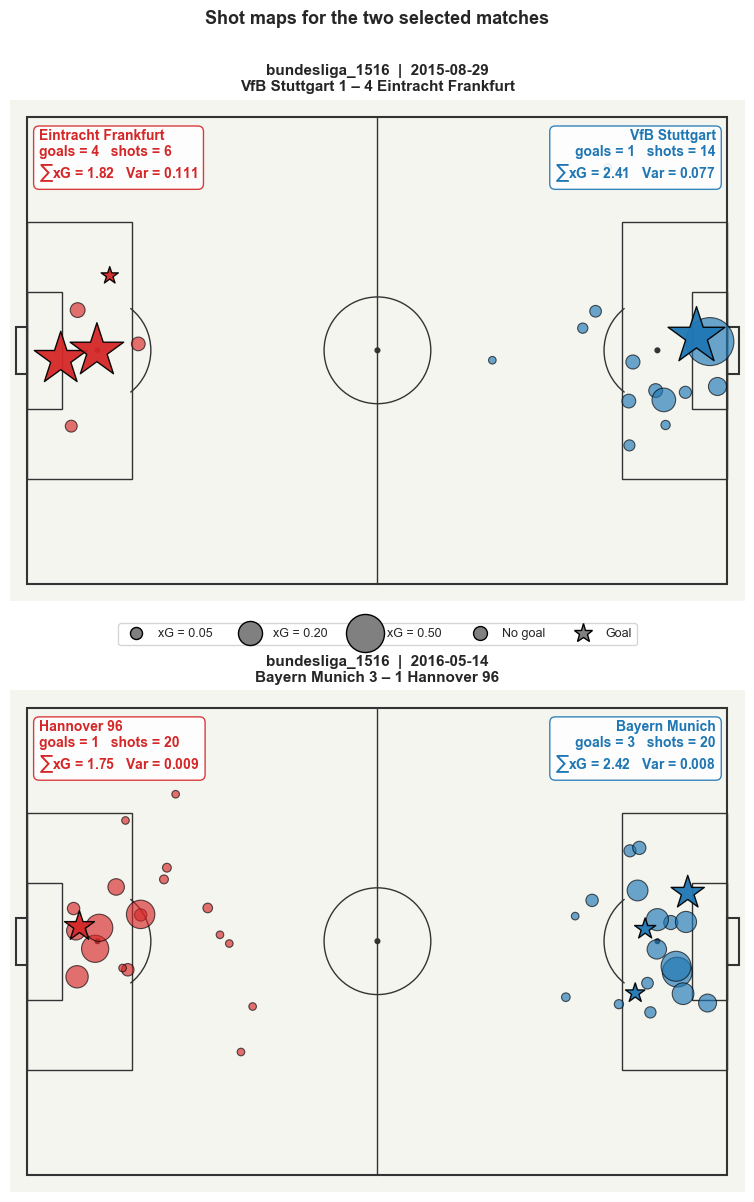

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(12, 12))
plot_shot_map(axes[0], m1, shots_m1)
plot_shot_map(axes[1], m2, shots_m2)

# Shared legend (size = xG; star = goal; circle = no goal).
size_handles = [
    Line2D([0], [0], marker='o', linestyle='', color='gray',
           markeredgecolor='black', markersize=np.sqrt(p * 1500),
           label=f'xG = {p:.2f}')
    for p in (0.05, 0.20, 0.50)
]
outcome_handles = [
    Line2D([0], [0], marker='o', linestyle='', color='gray', markeredgecolor='black',
           markersize=10, label='No goal'),
    Line2D([0], [0], marker='*', linestyle='', color='gray', markeredgecolor='black',
           markersize=14, label='Goal'),
]
axes[0].legend(handles=size_handles + outcome_handles, loc='lower center',
               ncol=5, frameon=True, fontsize=9, bbox_to_anchor=(0.5, -0.10))

fig.suptitle('Shot maps for the two selected matches', fontsize=13, fontweight='bold', y=1.00)
fig.tight_layout()
fig.savefig(FIG_DIR / 'applications_shot_maps.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Expected goal-count distributions (Poisson Binomial)

Using the per-shot xG values, the Poisson Binomial PMF gives the exact distribution of
goals for a team — the convolution of its individual Bernoulli shot trials
$\sum_k P(X=k)\,a^k = \prod_i [(1-p_i) + p_i a]$. We plot it for both teams in both
matches; the realised goal count is highlighted on each panel.

Even with nearly identical xG sums, the two matches have visibly different goal-count
PMFs because their shot variance profiles differ.

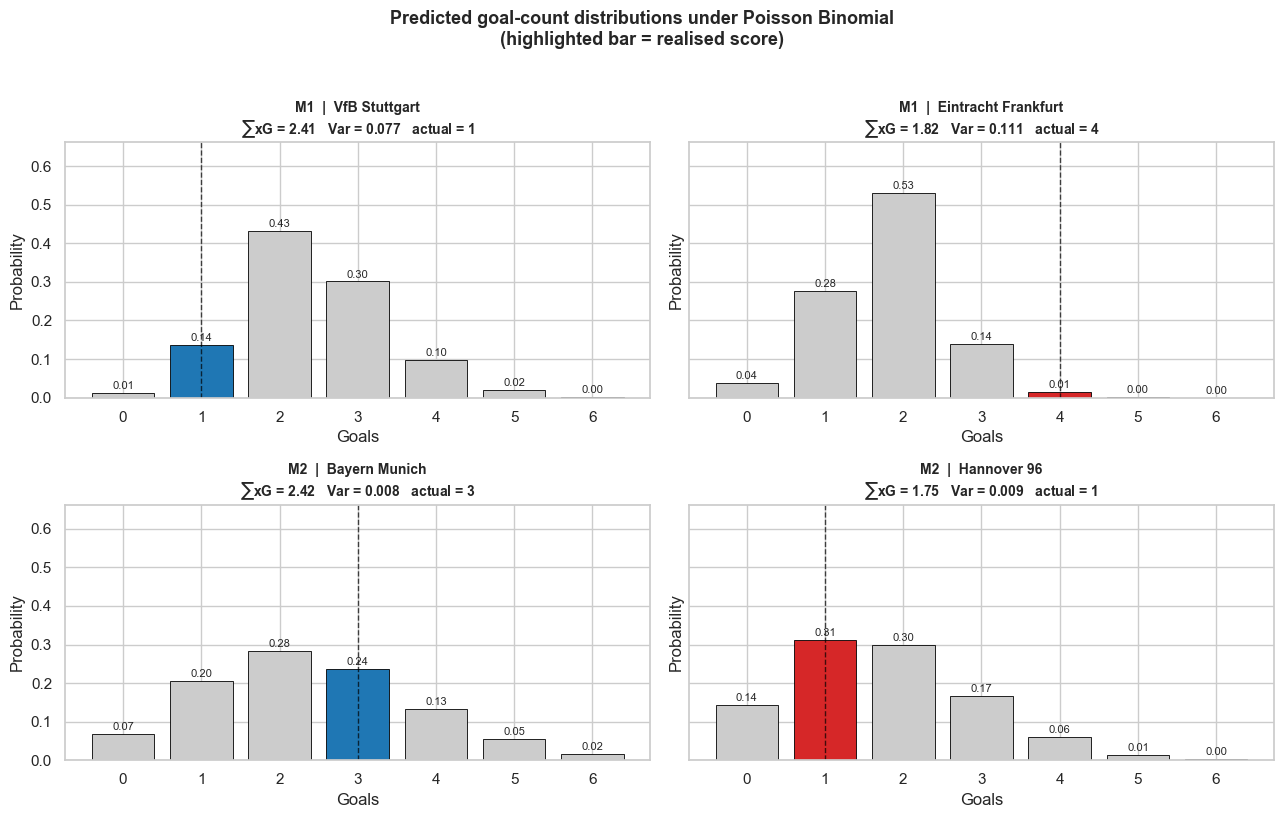

In [11]:
def pad(pmf, length):
    out = np.zeros(length); out[:len(pmf)] = pmf[:length]; return out

GOAL_DISPLAY = 7  # plot 0..6 goals

def pb_team_pmf(xg_list):
    return pad(poisson_binomial_pmf(xg_list), GOAL_DISPLAY)

panels = []
for tag, m in [('M1', m1), ('M2', m2)]:
    for side_label, color, xg_list, observed in [
        (m['home_team'], HOME_COLOR, m['home_xg_list'], int(m['home_goals'])),
        (m['away_team'], AWAY_COLOR, m['away_xg_list'], int(m['away_goals'])),
    ]:
        panels.append((tag, side_label, color, xg_list, observed, pb_team_pmf(xg_list)))
y_top = max(pmf.max() for *_, pmf in panels) * 1.25

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)
for ax, (tag, side_label, color, xg_list, observed, pmf) in zip(axes.flat, panels):
    bar_colors = [color if k == observed else '#cccccc' for k in range(GOAL_DISPLAY)]
    ax.bar(np.arange(GOAL_DISPLAY), pmf, color=bar_colors, edgecolor='black', linewidth=0.6)
    for k, p in enumerate(pmf):
        ax.text(k, p + 0.005, f'{p:.2f}', ha='center', va='bottom', fontsize=8)
    ax.axvline(observed, color='black', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xticks(range(GOAL_DISPLAY))
    ax.set_xlabel('Goals')
    ax.set_ylabel('Probability')
    ax.set_title(
        f"{tag}  |  {side_label}\n"
        f"$\\sum$xG = {sum(xg_list):.2f}   Var = {np.var(xg_list):.3f}   actual = {observed}",
        fontsize=10, fontweight='bold')
    ax.set_ylim(0, y_top)

fig.suptitle('Predicted goal-count distributions under Poisson Binomial\n(highlighted bar = realised score)',
             fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / 'applications_goal_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Three-outcome probabilities — Poisson Binomial vs Dixon–Coles

For each match we report:

- **Poisson Binomial**: home/away goal PMFs from `poisson_binomial_pmf(xg_values)`,
  combined into a joint scoreline matrix under independence, then aggregated to
  $(P(\text{home win}),\ P(\text{draw}),\ P(\text{away win}))$.
- **Dixon–Coles**: standard double-Poisson with rates $\lambda_h = $ home xG, $\lambda_a = $
  away xG, plus the four-cell low-score adjustment with $\rho$ fitted on the match's
  league.

The realised outcome is shown alongside.

In [12]:
def pb_outcome_and_matrix(m):
    h_pmf = pad(poisson_binomial_pmf(m['home_xg_list']), MAX_GOALS + 1)
    a_pmf = pad(poisson_binomial_pmf(m['away_xg_list']), MAX_GOALS + 1)
    mat   = scoreline_matrix_from_pmfs(h_pmf, a_pmf)
    return outcome_probs_from_scoreline(mat), mat

def dc_outcome_and_matrix(m, rho):
    mat = dixon_coles_matrix(float(m['home_xg']), float(m['away_xg']), rho, MAX_GOALS)
    return outcome_probs_from_scoreline(mat), mat

def _actual(m):
    h, a = int(m['home_goals']), int(m['away_goals'])
    if h > a: return 'home_win'
    if h < a: return 'away_win'
    return 'draw'

rows = []
matrices = {}
for tag, m in [('M1', m1), ('M2', m2)]:
    rho = rho_by_league[m['league_slug']]
    pb_p, pb_m = pb_outcome_and_matrix(m)
    dc_p, dc_m = dc_outcome_and_matrix(m, rho)
    matrices[tag] = {'PB': pb_m, 'DC': dc_m, 'm': m, 'rho': rho}
    label = (f"{tag}: {m['home_team']} {int(m['home_goals'])}-{int(m['away_goals'])} {m['away_team']}"
             f"  ({m['match_date']})")
    rows.append({'Match': label, 'Approach': 'Poisson Binomial',
                 'P(home win)': pb_p['p_home_win'], 'P(draw)': pb_p['p_draw'], 'P(away win)': pb_p['p_away_win'],
                 'Actual': _actual(m), 'rho_DC': ''})
    rows.append({'Match': label, 'Approach': 'Dixon-Coles',
                 'P(home win)': dc_p['p_home_win'], 'P(draw)': dc_p['p_draw'], 'P(away win)': dc_p['p_away_win'],
                 'Actual': _actual(m), 'rho_DC': f'{rho:+.4f}'})

outcome_table = pd.DataFrame(rows)
outcome_table[['P(home win)', 'P(draw)', 'P(away win)']] = outcome_table[['P(home win)', 'P(draw)', 'P(away win)']].round(3)
outcome_table

,Match,Approach,P(home win),P(draw),P(away win),Actual,rho_DC
0,M1: VfB Stuttgart 1-4 Eintracht Frankfurt (20...,Poisson Binomial,0.515,0.310,0.175,away_win,
1,M1: VfB Stuttgart 1-4 Eintracht Frankfurt (20...,Dixon-Coles,0.509,0.202,0.289,away_win,-0.0647
2,M2: Bayern Munich 3-1 Hannover 96 (2016-05-14),Poisson Binomial,0.534,0.206,0.259,home_win,
3,M2: Bayern Munich 3-1 Hannover 96 (2016-05-14),Dixon-Coles,0.525,0.201,0.273,home_win,-0.0647


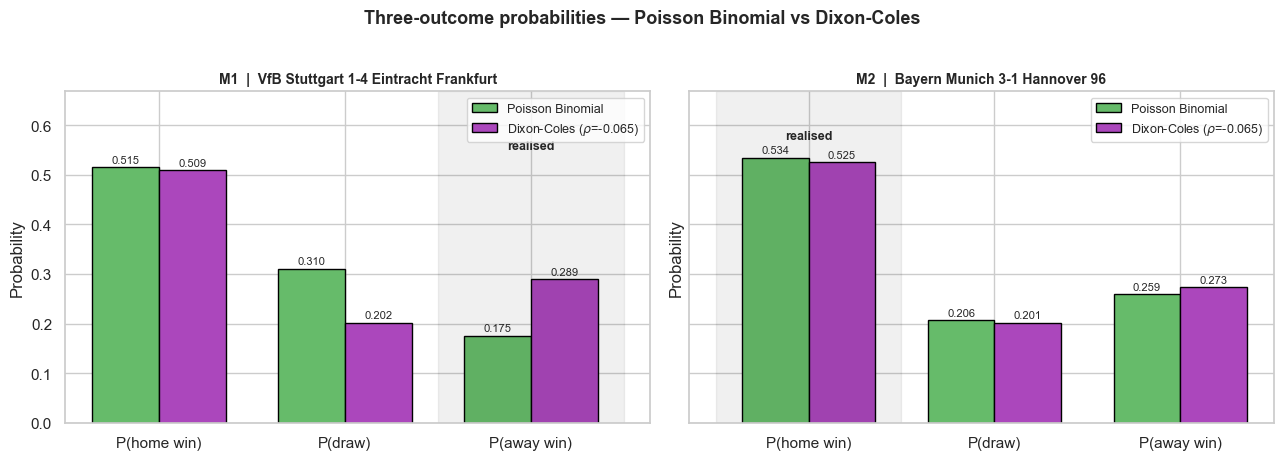

In [13]:
OUT_LABELS = ['P(home win)', 'P(draw)', 'P(away win)']
OUT_KEYS   = ['p_home_win', 'p_draw', 'p_away_win']
OUT_ACT    = ['home_win',   'draw',   'away_win']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, (tag, info) in zip(axes, matrices.items()):
    m, rho = info['m'], info['rho']
    pb = outcome_probs_from_scoreline(info['PB'])
    dc = outcome_probs_from_scoreline(info['DC'])
    actual_outcome = _actual(m)
    pb_vals = [pb[k] for k in OUT_KEYS]
    dc_vals = [dc[k] for k in OUT_KEYS]
    x = np.arange(len(OUT_LABELS))
    w = 0.36
    bars_pb = ax.bar(x - w/2, pb_vals, width=w, color='#66BB6A', edgecolor='black',
                     label='Poisson Binomial')
    bars_dc = ax.bar(x + w/2, dc_vals, width=w, color='#AB47BC', edgecolor='black',
                     label=f'Dixon-Coles ($\\rho$={rho:+.3f})')
    # Highlight the actual outcome with a vertical band
    actual_idx = OUT_ACT.index(actual_outcome)
    ax.axvspan(actual_idx - 0.5, actual_idx + 0.5, color='black', alpha=0.06)
    ax.text(actual_idx, max(max(pb_vals), max(dc_vals)) * 1.06, 'realised',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
    for bars, vals in [(bars_pb, pb_vals), (bars_dc, dc_vals)]:
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width() / 2, v + 0.005, f'{v:.3f}',
                    ha='center', va='bottom', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(OUT_LABELS)
    ax.set_ylim(0, max(max(pb_vals), max(dc_vals)) * 1.25)
    ax.set_ylabel('Probability')
    ax.set_title(
        f"{tag}  |  {m['home_team']} {int(m['home_goals'])}-{int(m['away_goals'])} {m['away_team']}",
        fontsize=10, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')

fig.suptitle('Three-outcome probabilities — Poisson Binomial vs Dixon-Coles',
             fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / 'applications_outcome_probs.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Scoreline heatmaps with realised score highlighted

Heatmaps of $P(\text{home}=h,\ \text{away}=a)$ for $h, a \in \{0, \ldots, 10\}$ under both
approaches. The cell corresponding to the realised score is outlined in black.

Where the Poisson Binomial concentrates probability differently from the sum-based
Dixon–Coles is exactly where the per-shot xG variance carries information.

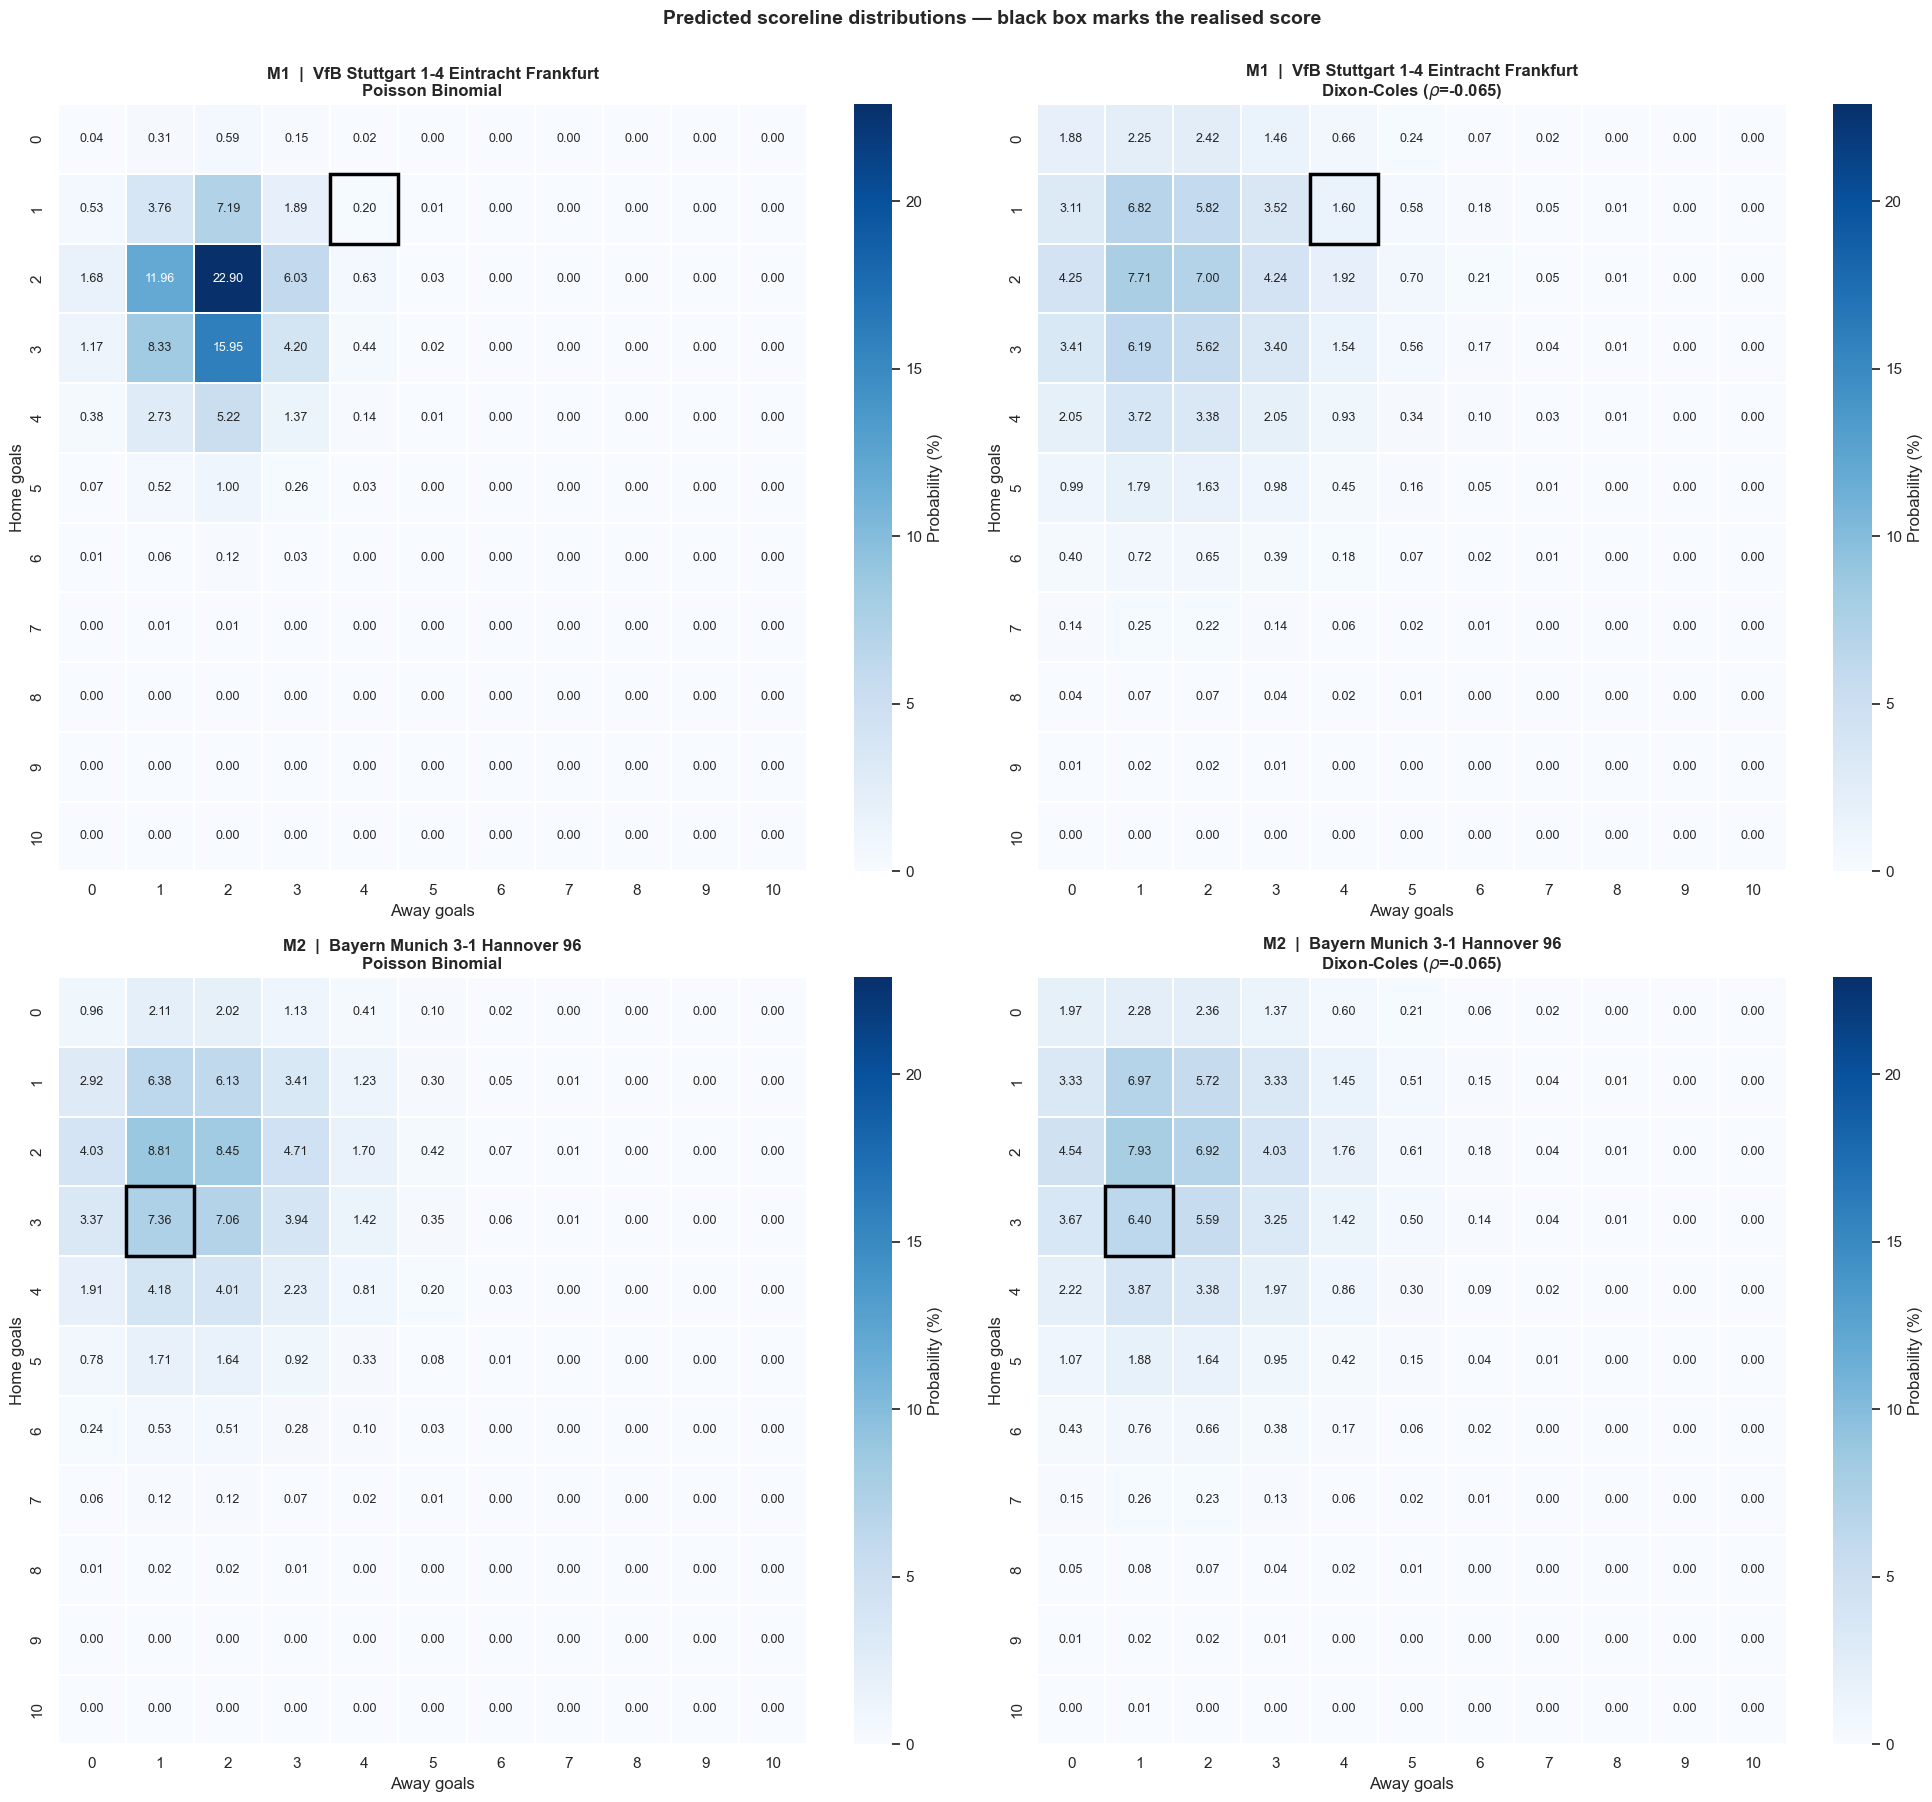

In [14]:
DISPLAY = MAX_GOALS + 1  # 0..10 on each axis

def annotate_actual(ax, h, a):
    # Heatmap rows = home, cols = away. Cell (h, a) lives at xy = (a, h).
    ax.add_patch(Rectangle((a, h), 1, 1, fill=False, edgecolor='black',
                           linewidth=2.5, zorder=10))

vmax = max(
    matrices['M1']['PB'][:DISPLAY, :DISPLAY].max(),
    matrices['M1']['DC'][:DISPLAY, :DISPLAY].max(),
    matrices['M2']['PB'][:DISPLAY, :DISPLAY].max(),
    matrices['M2']['DC'][:DISPLAY, :DISPLAY].max(),
)

fig, axes = plt.subplots(2, 2, figsize=(20, 18))
for row, (tag, info) in enumerate(matrices.items()):
    m = info['m']
    for col, (approach_label, approach_key) in enumerate([
        ('Poisson Binomial', 'PB'),
        (f"Dixon-Coles ($\\rho$={info['rho']:+.3f})", 'DC'),
    ]):
        ax = axes[row, col]
        mat = info[approach_key][:DISPLAY, :DISPLAY] * 100
        sns.heatmap(
            mat, ax=ax, annot=True, fmt='.2f',
            cmap='Blues', vmin=0, vmax=vmax * 100,
            xticklabels=range(DISPLAY), yticklabels=range(DISPLAY),
            cbar_kws={'label': 'Probability (%)'},
            linewidths=0.3, linecolor='white', annot_kws={'size': 9},
        )
        ax.set_xlabel('Away goals'); ax.set_ylabel('Home goals')
        ax.set_title(
            f"{tag}  |  {m['home_team']} {int(m['home_goals'])}-{int(m['away_goals'])} {m['away_team']}\n"
            f"{approach_label}",
            fontsize=12, fontweight='bold')
        annotate_actual(ax, int(m['home_goals']), int(m['away_goals']))

fig.suptitle('Predicted scoreline distributions — black box marks the realised score',
             fontsize=14, fontweight='bold', y=1.00)
fig.tight_layout()
fig.savefig(FIG_DIR / 'applications_scoreline_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()

## What to take from this

Both matches feed Dixon–Coles (and Double Poisson, Bivariate Poisson) the same input —
essentially $(\lambda_h \approx 2.4,\ \lambda_a \approx 1.8)$ — so those models produce
near-identical forecasts for the two. The Poisson Binomial sees the per-shot xG
structure that the sum-based models throw away, so its predicted goal- and scoreline
distributions are visibly different between the two matches: tighter and more
concentrated where shots are uniform-quality, more right-skewed where a few big chances
drive the team's xG total. This is the per-match-level mechanism behind the aggregate
improvements documented in `02_evaluation.ipynb` and `EXPERIMENT_SUMMARY.md`.